### 📥 Import Required Libraries


In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load the Image



In [39]:
img = cv2.cvtColor(cv2.imread('snow.jpg'),cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

## Snow Scene

Consider an image of a snowy landscape.

In this type of image, almost all regions appear bright because snow is naturally white. As a result, most pixels have high intensity values, while only a small number of pixels belong to dark regions.

If we plot the histogram of this image, we observe that most intensity values are concentrated near the upper end of the histogram (close to **255**), with very few pixels occupying the darker intensity levels.

This behavior is completely expected because the scene itself is naturally bright.

Therefore, a histogram concentrated in the high-intensity range does **not** necessarily indicate poor image quality or low contrast. Instead, it accurately reflects the true brightness distribution of the scene.


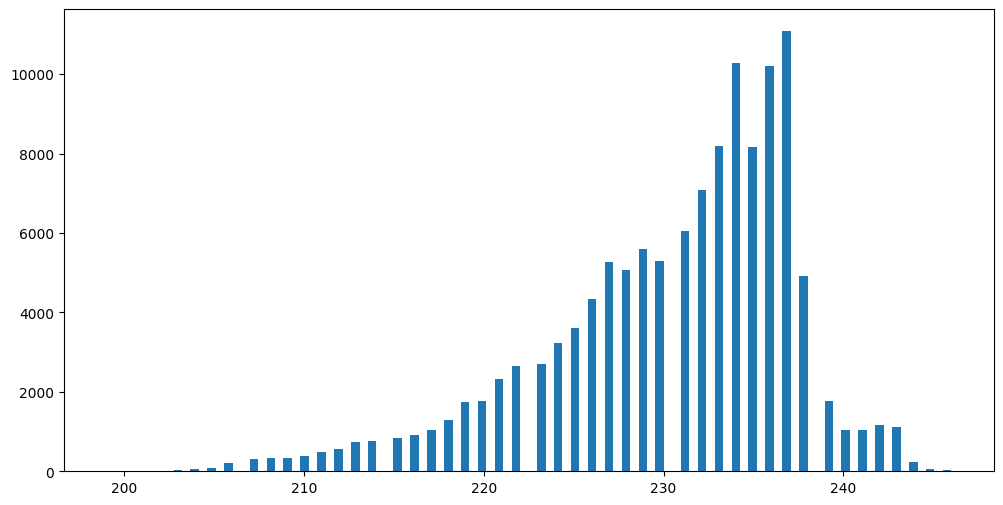

In [40]:
plt.figure(figsize=(12,6))
plt.hist(img_gray.reshape(-1),bins=100)
plt.show()

###  Histogram Stretching on RGB Channels


In [41]:
# color image
stretched_channels = []
img_channel = cv2.split(img)

for i, ch in enumerate(img_channel):

    i_min = ch.min()
    i_max = ch.max()

    ch_stretched = ((ch - i_min) / (i_max - i_min) * 255).astype(np.uint8)
    stretched_channels.append(ch_stretched)

img_rgb_stretched = cv2.merge(stretched_channels)

### Compare the Original and Enhanced Color Images


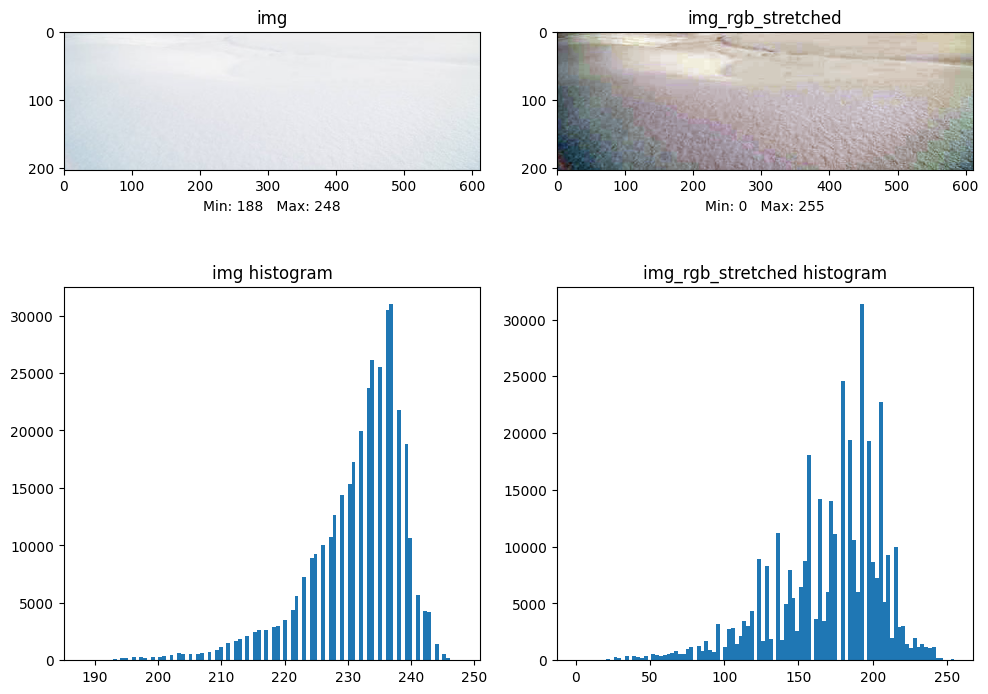

In [42]:
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(img)
plt.title("img")
plt.xlabel(f"Min: {img.min()}   Max: {img.max()}")

plt.subplot(2,2,2)
plt.imshow(img_rgb_stretched, cmap='gray')
plt.title("img_rgb_stretched")
plt.xlabel(f"Min: {img_rgb_stretched.min()}   Max: {img_rgb_stretched.max()}")

plt.subplot(2,2,3)
plt.hist(img.reshape(-1), bins=100)
plt.title("img histogram")

plt.subplot(2,2,4)
plt.hist(img_rgb_stretched.reshape(-1), bins=100)
plt.title("img_rgb_stretched histogram")

plt.tight_layout()
plt.show()

## What Happens If We Apply Histogram Stretching?

The goal of **Histogram Stretching** is to expand the range of intensity values in an image so that it spans the entire available grayscale range (0–255).

In the snow image, however, the histogram is already concentrated in the high-intensity region, approximately between **200 and 255**.

When Histogram Stretching is applied, this narrow range is linearly mapped to the full **0–255** intensity range.

As a result:

* Bright regions are shifted toward lower intensity values.
* Areas that should naturally appear white become gray or even noticeably darker.
* The original visual appearance of the scene is distorted.

The algorithm assumes that the image suffers from low contrast and therefore attempts to enhance it. In reality, the image is already correctly exposed—the dominance of bright pixels is simply a characteristic of the scene itself.

For this reason, applying Histogram Stretching produces an unrealistic result and degrades the natural appearance of the image instead of improving it.


# histogram equalization

In [43]:
# color image
equ_channels = []
img_channel = cv2.split(img)
for ch in img_channel:
    ch_equ = cv2.equalizeHist(ch)
    equ_channels.append(ch_equ)

img_rgb_equ = cv2.merge(equ_channels)

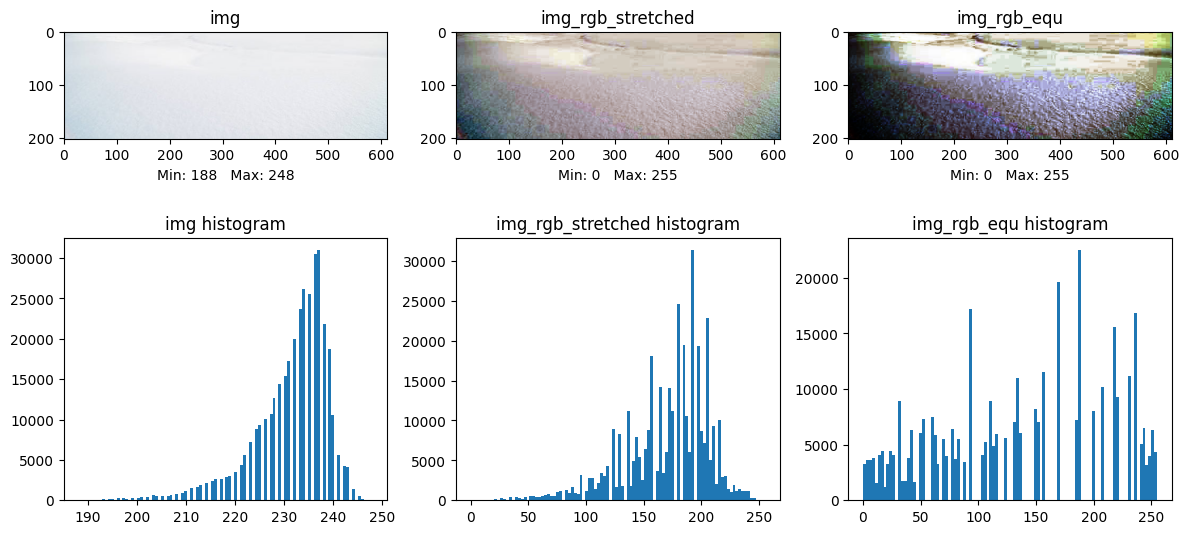

In [44]:

plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(img)
plt.title("img")
plt.xlabel(f"Min: {img.min()}   Max: {img.max()}")

plt.subplot(2,3,2)
plt.imshow(img_rgb_stretched, cmap='gray')
plt.title("img_rgb_stretched")
plt.xlabel(f"Min: {img_rgb_stretched.min()}   Max: {img_rgb_stretched.max()}")

plt.subplot(2,3,3)
plt.imshow(img_rgb_equ, cmap='gray')
plt.title("img_rgb_equ")
plt.xlabel(f"Min: {img_rgb_equ.min()}   Max: {img_rgb_equ.max()}")


plt.subplot(2,3,4)
plt.hist(img.reshape(-1), bins=100)
plt.title("img histogram")

plt.subplot(2,3,5)
plt.hist(img_rgb_stretched.reshape(-1), bins=100)
plt.title("img_rgb_stretched histogram")

plt.subplot(2,3,6)
plt.hist(img_rgb_equ.reshape(-1), bins=100)
plt.title("img_rgb_equ histogram")

plt.tight_layout()
plt.show()

## What Happens If We Apply Histogram Equalization?

Compared with Histogram Stretching, **Histogram Equalization** produces much more aggressive intensity transformations.

The objective of this method is to redistribute pixel intensities so that the histogram becomes more uniform, making use of almost the entire available intensity range.

For naturally bright images, such as snowy scenes, the results are usually undesirable.

For example:

* Snow-covered regions may appear gray instead of white.
* Some areas become excessively bright and lose visual detail.
* Regions that should remain bright may appear unnaturally dark or even nearly black.



## Why Does This Happen?

The main reason is that both **Histogram Stretching** and **Histogram Equalization** are **global** enhancement techniques.

In other words, the entire image is represented by a single histogram, and all enhancement decisions are made based on this overall intensity distribution.

As a result, the algorithm does not consider the actual content of the image. It cannot distinguish whether a pixel belongs to:

* Snow
* A tree trunk
* A shadowed region
* The sky

Instead, every pixel is modified solely according to its intensity value.

Because the spatial structure and semantic content of the image are ignored, the resulting enhancement may distort the natural appearance of the scene rather than improve it.


## Contrast Enhancement in HSV Color Space



In [45]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
h,s,v = cv2.split(img_hsv)

v_min = v.min()
v_max = v.max()
print("min v:" , v_min)
print("max v:" , v_max)

v_stretch = (((v - v_min) / (v_max - v_min)) * 255).astype('uint8')

v_stretch_min = v_stretch.min()
v_stretch_max = v_stretch.max()
print("min v_stretch:" , v_stretch_min)
print("max v_stretch:" , v_stretch_max)


img_hsv_stretched = cv2.merge([h,s,v_stretch])

v_equ = cv2.equalizeHist(v)

img_hsv_equ = cv2.merge([h,s,v_equ])


img_hsv_show = cv2.cvtColor(img_hsv,cv2.COLOR_HSV2RGB)
img_hsv_stretched_show = cv2.cvtColor(img_hsv_stretched,cv2.COLOR_HSV2RGB)
img_hsv_equ_show = cv2.cvtColor(img_hsv_equ,cv2.COLOR_HSV2RGB)


min v: 211
max v: 248
min v_stretch: 0
max v_stretch: 255


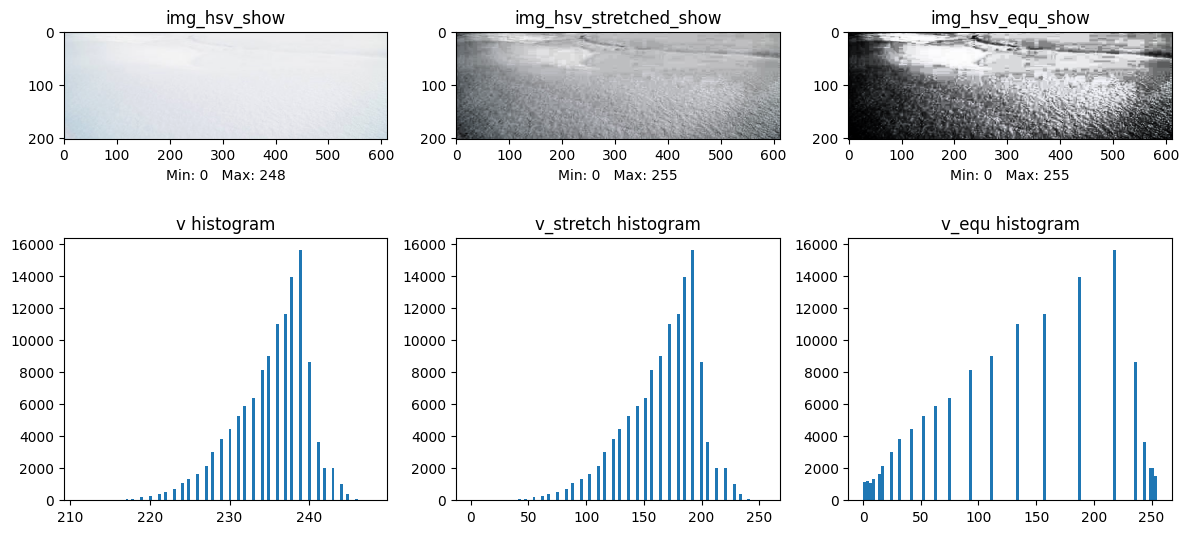

In [46]:

img_gray_eq = cv2.equalizeHist(img_gray)

plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(img_hsv_show)
plt.title("img_hsv_show")
plt.xlabel(f"Min: {img_hsv.min()}   Max: {img_hsv.max()}")

plt.subplot(2,3,2)
plt.imshow(img_hsv_stretched_show)
plt.title("img_hsv_stretched_show")
plt.xlabel(f"Min: {v_stretch.min()}   Max: {v_stretch.max()}")

plt.subplot(2,3,3)
plt.imshow(img_hsv_equ_show, cmap='gray')
plt.title("img_hsv_equ_show")
plt.xlabel(f"Min: {v_equ.min()}   Max: {v_equ.max()}")


plt.subplot(2,3,4)
plt.hist(v.reshape(-1), bins=100)
plt.title("v histogram")

plt.subplot(2,3,5)
plt.hist(v_stretch.reshape(-1), bins=100)
plt.title("v_stretch histogram")

plt.subplot(2,3,6)
plt.hist(v_equ.reshape(-1), bins=100)
plt.title("v_equ histogram")

plt.tight_layout()
plt.show()

## Why Is This a Problem?

Snow is naturally white, so we expect most snowy regions to remain white after image enhancement. However, when **Histogram Stretching** is applied, some parts of the snow become gray or even darker, causing the image to lose its natural appearance.

This problem becomes even more severe with **Histogram Equalization**. Since this method aggressively redistributes pixel intensities to maximize contrast, it often introduces significant changes to the image. Although the primary goal of Histogram Equalization is to increase contrast, higher contrast does not always lead to better image quality.

In snowy scenes, this excessive contrast enhancement can cause:

* Snow-covered regions to become gray or unnaturally dark.
* Some areas to become excessively bright.
* The natural brightness balance of the scene to be lost.

As a result, the enhanced image no longer represents the real scene accurately and appears visually unrealistic.
